In [385]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers
import time

In [386]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [387]:
def pathGenerator(v, segments, g, bVal, eps = 0.001, maxSteps = 20, maxR = 10): 
    x0 = v
    path = []
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        if r < eps: 
            return path, g(x0, segments, bVal, eps)
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
        
    #resample the path if length 0!!
    
    #return pathGenerator(v, segments, g)
    return pathGenerator(v, segments, g, bVal)

In [388]:
# set up the problem
#segments = [np.array([[-1, -1], [-1, 1]]), 
#            np.array([[-1, -1], [1, -1]]), 
#            np.array([[1, -1], [1, 1]]), 
#            np.array([[-1, 1], [1, 1]]),
#            np.array([[-0.3, 0], [0, 0]]),
#            np.array([[0, 0], [0.3, 0]]),
#            np.array([[0, -0.3], [0, 0]]),
#            np.array([[0, 0], [0, 0.3]]),
#            np.array([[0.8, 0], [0.6, 0.2]]),
#            np.array([[0.6, 0.2], [0.4, 0.4]]),
#            np.array([[0.4, 0.4], [0.2, 0.6]]),
#            np.array([[0.2, 0.6], [0, 0.8]]),
#            np.array([[0, 0.8], [-0.2, 0.6]]),
#            np.array([[-0.2, 0.6], [-0.4, 0.4]]),
#            np.array([[-0.4, 0.4], [-0.6, 0.2]]),
#            np.array([[-0.6, 0.2], [-0.8, 0]]),
#            np.array([[-0.8, 0], [-0.6, -0.2]]),
#            np.array([[-0.6, -0.2], [-0.4, -0.4]]),
#            np.array([[-0.4, -0.4], [-0.2, -0.6]]),
#            np.array([[-0.2, -0.6], [0, -0.8]])
#           ]
#v = np.array([0, 0])

segments = [np.array([[-1, -1], [-1, 1]]), 
            np.array([[-1, -1], [1, -1]]), 
            np.array([[1, -1], [1, 1]]), 
            np.array([[-1, 1], [1, 1]]),
            np.array([[0.8, 0], [0.4, 0.4]]),
            np.array([[0.4, 0.4], [0, 0.8]]),
            np.array([[0, 0.8], [-0.4, 0.4]]),
            np.array([[-0.4, 0.4], [-0.8, 0]]),
            np.array([[-0.8, 0], [-0.4, -0.4]]),
            np.array([[-0.4, -0.4], [0, -0.8]])
           ]

#boundVal = [0, 0, 0, 0, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1]

def boundary(v, segments, boundVal, eps):
    for i in range(0, len(boundVal)):
        u = closestPoint(v, segments[i])
        #print(segments[i])
        if norm(v - u) < eps:
            if i <= 3:
                return 0
            elif i == 4:
                return -2.5 * v[0] + 2
            elif i == 5 or i == 6:
                return 2.5 * v[0]
            elif i == 7:
                return -2.5 * v[0] - 2
            elif i == 8:
                return 2.5 * v[0] + 2
            elif i == 9:
                return -2.5 * v[0]
        
    return 0 

In [389]:
tic = time.perf_counter()#timer
#####evenly distributed start places
#target = []
#width = range(1, 200)
#height = range(1, 200)
#for i in width:
#    for j in height:
#        target.append(np.array([i/100 - 1, j/100 - 1]))
        
#target = np.tile(target_core, [100, 1])
#print(target.shape)

#print(len(target))

###### pure random start places
target = np.random.rand(100000, 2)
target = 2* target - 1

#####QMC start places
#import scipy.stats as stats
#qmcGenerator = stats.qmc.Sobol(d=2)
#target = qmcGenerator.random(n=100000)
#target = 2* target - 1
#target = target[(target[:,0] <= 0) | (target[:,1] <= 0)]
#print(target.shape)

#####Single start place at center
#target = np.zeros((40000, 2))


In [390]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = pathGenerator(v, segments, boundary, boundVal)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)


In [391]:
paths1 = np.zeros((len(paths), maxPath, 2))
for i in range(len(paths)):
    path = paths[i]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 2)) * np.array(path[len(path) - 1])))

    paths1[i] = npath

print("Total path amount: ")
print(paths1.shape)
tac = time.perf_counter()
print("WoSNN sample time: " + str(tac - tic))

Total path amount: 
(100000, 20, 2)
WoSNN sample time: 44.27923341697897


In [392]:
paths1 = paths1.reshape(-1, maxPath, 2).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

[-0.016629658395608926, -0.07047963419844194, 0, 0, 0.2567079248705585, 0.35716699323232026, 0, -0.49646573842353536, 0.00013012115903587862, 0.4174064047305251, -0.22331422526042724, 0, 0.005965654811537987, 0, 0.29514766107465623, -0.6757072133345489, -0.6216909192914488, 0.46630643542963335, -0.07787781953671802, 0, 0.33663088180581, 0, 0.5309894867087324, -0.7278484387623361, 0, 0, 0.18238819427502595, 0.060674441015542105, 0.0599899570634681, 0.7901920798471539, 0, 0, 0.770991672809913, 0, 0.3909954752834993, 0.0001714075162346212, 0.11168805788313987, -0.6972934014379261, -0.10816266548878328, 0.7773177019429769, 0, 0.5804152304272105, 0, 0, 0, -0.17658965549155203, 0, -0.33122668061554794, -0.7447738269489395, -0.9075589357285468, 0.536916698714349, 0, -0.6249334076421103, 0.24354143850957133, -0.39036265669406545, 0.56620034345311, 0.595385341282072, 0, 0, -0.9375733571736478, 0, 0, -0.7122495566778608, 0.266945150542806, 0, -0.1547762457899271, 0.8589437621211199, 0, 0, 0, 0.1

In [393]:
class NN(keras.Model):
    def __init__(self, units):
        super(NN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(3)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [394]:
class Ysolver(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layer):
        super(Ysolver, self).__init__()
        self.model = NN(layer)

        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training, batch):
        #print(path.shape)
        y_pred = self.model(path[:, 0], training)[:, 0]
        #print(y_pred.shape)
        for i in range(len(path[0]) - 1): ###input path should be (-1, 2) shaped nparray, no len()
            #y = self.Ymodel(path[:, i], training)
            #print(y.shape)
            #z_input = tf.concat([path[:, i],y], 1)
            z = self.model(path[:, i], training)[:, 1:3] #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            add = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1] #accumulating
            #print(add.shape)
            y_pred += add

        return y_pred

In [395]:
class NNsolver(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver([64, 64, 128])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.reduce_mean(tf.square(delta))
        return loss

    def train_step(self, cur_path, training, batch_size):           
        return self.model(cur_path, training, batch_size)

    def train(self, batch_size): 
        training_history = []
        for i in range((len(self.paths) - 1)//batch_size + 1):
            batch = batch_size
            if (i + 1) * batch_size > len(paths):
                batch = len(paths) - i * batch_size
            cur_path = self.paths[i*batch_size: i*batch_size + batch]
            cur_bound = self.boundary[i*batch_size: i*batch_size + batch]
                
            with tf.GradientTape() as tape:
                y_pred = self.train_step(cur_path, training = True, batch_size=batch)
                loss = self.loss_fn(y_pred, cur_bound)

            training_vars = self.model.trainable_variables 
            grad = tape.gradient(loss, training_vars)
            #print(grad)
            #print("----------------------------------------------------")
            self.optimizer.apply_gradients(zip(grad, training_vars))
            #print(self.model.Ymodel.trainable_variables)
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch, batch_size):
        for i in range(epoch):
            cur_history = self.train(batch_size)
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [396]:
tic = time.perf_counter()
training = NNsolver(paths1, boundary1)
training.train_epoch(200, 2048)
tac = time.perf_counter()
print("WoSNN training time: " + str(tac - tic))

epoch: 0 loss: 0.1459903
epoch: 1 loss: 0.087712266
epoch: 2 loss: 0.043626755
epoch: 3 loss: 0.03412251
epoch: 4 loss: 0.03175951
epoch: 5 loss: 0.030366078
epoch: 6 loss: 0.029234735
epoch: 7 loss: 0.028108278
epoch: 8 loss: 0.027128626
epoch: 9 loss: 0.026249273
epoch: 10 loss: 0.025433216
epoch: 11 loss: 0.024658853
epoch: 12 loss: 0.023972187
epoch: 13 loss: 0.02338294
epoch: 14 loss: 0.022883128
epoch: 15 loss: 0.022462957
epoch: 16 loss: 0.022097412
epoch: 17 loss: 0.021799056
epoch: 18 loss: 0.021560933
epoch: 19 loss: 0.021373335
epoch: 20 loss: 0.021216124
epoch: 21 loss: 0.021081716
epoch: 22 loss: 0.02096699
epoch: 23 loss: 0.020862833
epoch: 24 loss: 0.020772412
epoch: 25 loss: 0.02069342
epoch: 26 loss: 0.020620838
epoch: 27 loss: 0.020555543
epoch: 28 loss: 0.020499442
epoch: 29 loss: 0.020444702
epoch: 30 loss: 0.020395033
epoch: 31 loss: 0.020347355
epoch: 32 loss: 0.02029989
epoch: 33 loss: 0.020257482
epoch: 34 loss: 0.020219427
epoch: 35 loss: 0.020184865
epoch: 36 

In [397]:
print(training.model.model(np.array([0.5, 0.5]).reshape([1, 2]).astype("float32")))

tf.Tensor([[ 0.58720404 -1.4350264  -1.4868964 ]], shape=(1, 3), dtype=float32)


In [398]:
tic = time.perf_counter()
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        #if (i/50 - 1) <= 0 or (j/50 - 1) <= 0:
        Z.append(training.model.model(np.array([i/50 - 1 ,j/50 - 1]).reshape([1, 2]).astype("float32")))
        #else:
        #Z.append(np.array([[1, 0, 0]])) 

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)
tac = time.perf_counter()
print("WoSNN testing time: " + str(tac - tic))


WoSNN testing time: 2.45857754201279


In [399]:
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)

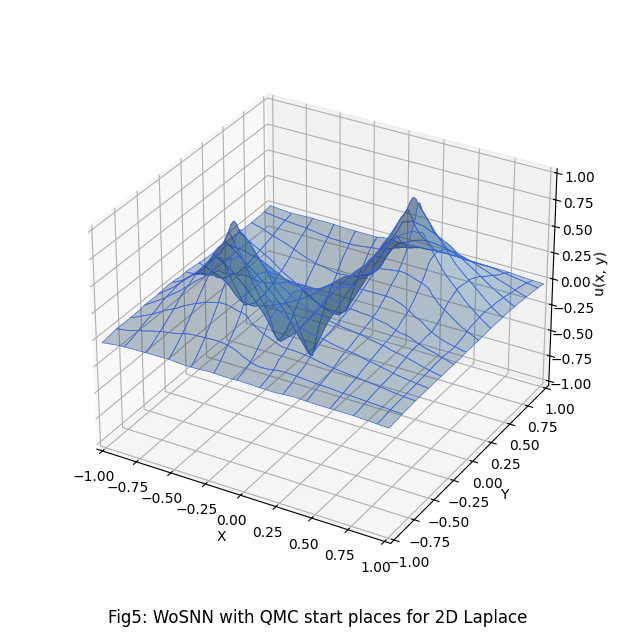

In [400]:
Z1 = X*Y

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
#ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='u(x, y)')

#ax.view_init(30, 90)
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig5: WoSNN with QMC start places for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSNNqmc2Dlaplace.png', bbox_inches='tight')

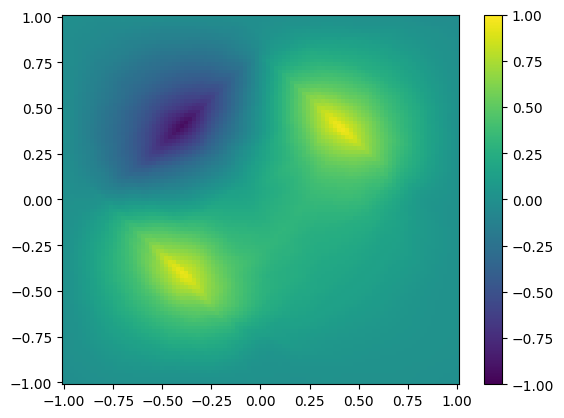

In [401]:
#z_min, z_max = -np.abs(Z2).max(), np.abs(Z2).max()
fig, ax = plt.subplots()
c = ax.pcolormesh(X, Y, Z2, cmap = 'viridis', vmin = -1, vmax = 1)
#ax.axis([-1, 1, -1, 1])
fig.colorbar(c, ax = ax)
#plt.show()
plt.savefig('WoSNNLregion.png', bbox_inches='tight')

In [402]:

print("WoSNN mean error for 10000 test points: " + str(np.mean(abs(Z2-Z1))))

WoSNN mean error for 10000 test points: 0.30993253145821803


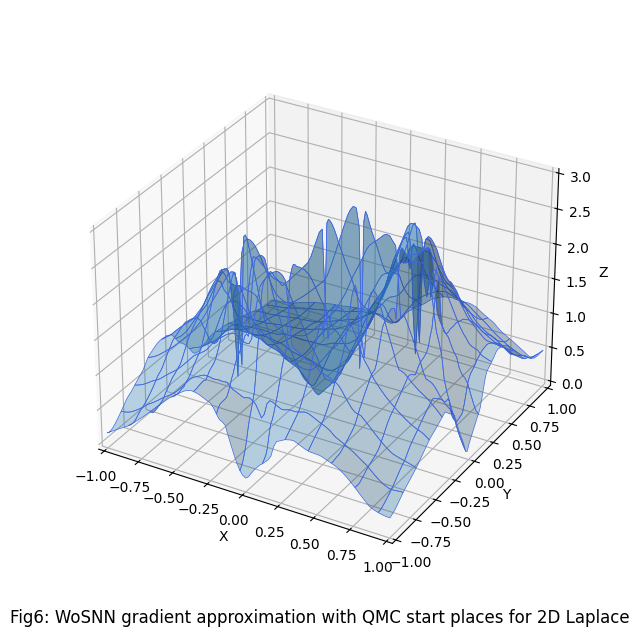

In [410]:
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:3].reshape(-1, 2), axis = 1).reshape(101, 101)
Z1 = np.sqrt(X*X + Y*Y)

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
#ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 3),
       xlabel='X', ylabel='Y', zlabel='Z')

ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig6: WoSNN gradient approximation with QMC start places for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSNN2DqmclaplaceGradient.png', bbox_inches='tight')

In [404]:
print("WoSNN mean gradient error for 10000 test points: " + str(np.mean(abs(Z3-Z1))))

WoSNN mean gradient error for 10000 test points: 0.7332520513951374


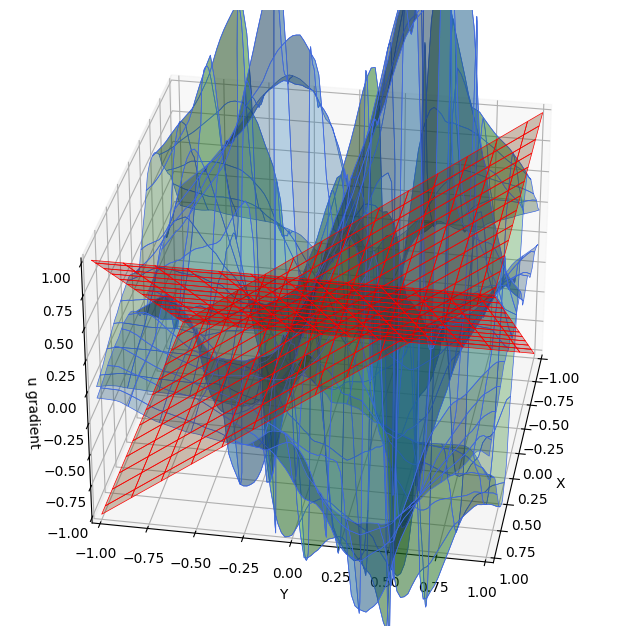

In [405]:
X1 = np.array(Z)[:, :, 1].reshape(101, 101)
X2 = Y
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = X

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, X1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of x')
ax.plot_surface(X, Y, X2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of y')
ax.plot_surface(X, Y, Y2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='u gradient')

ax.view_init(30, 10)

#ax.set_box_aspect(None, zoom=0.85)
#ax.set_title("Fig4: WoSNN gradient approximation with evenly distributed start places for 2D Laplace", y=-0.01)
plt.show()
#plt.savefig('WoSNNeven2DlaplaceGradient.png', bbox_inches='tight')

(101, 101)


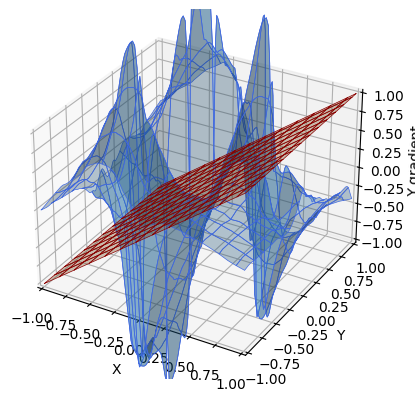

In [406]:
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = X
print(Y1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Y2, edgecolor='darkred', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='Y gradient')

plt.show()

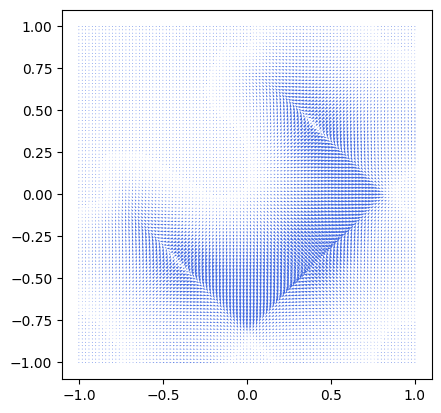

In [407]:
x = np.arange(-1, 1.02, 0.02)
y = np.arange(-1, 1.02, 0.02)
 
# Creating gradient
X, Y = np.meshgrid(x, y)
Z4 = X * Y
dx, dy = np.gradient(Z4)
Z3 = np.array(Z)[:, :, 1:3].reshape(-1, 2)

 
# Creating plot 
fig, ax = plt.subplots()
#ax.quiver(X, Y, dx, dy, color = 'red')
ax.quiver(X, Y, Z3[:, 0].reshape(101, 101), Z3[:, 1].reshape(101, 101), color = 'royalblue')
 
#ax.xaxis.set_ticks([])
#ax.yaxis.set_ticks([])
ax.set_aspect('equal')
 
# show plot
plt.show()

In [408]:
paths1[1]

array([[-0.67520654,  0.05053382],
       [-0.70654976,  0.00840486],
       [-0.7629174 ,  0.02935841],
       [-0.7600211 ,  0.0247277 ],
       [-0.76675165,  0.01630162],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567],
       [-0.77180815,  0.02716567]], dtype=float32)

In [409]:
target

array([[-0.78201826,  0.03004569],
       [-0.67520655,  0.05053382],
       [ 0.60055101, -0.36993188],
       ...,
       [-0.96405024,  0.42092697],
       [-0.2762165 , -0.17156485],
       [-0.14758335,  0.86910391]])